In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import requests
import os
import pandas as pd
import numpy as np
from PIL import Image
import time
import cv2
import matplotlib.pyplot as plt

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import requests
import os
import pandas as pd
import numpy as np
from PIL import Image
import sys

# ==========================================
# 1. ROBUST MAPILLARY DOWNLOADER
# ==========================================
class MapillaryDownloader:
    def __init__(self, token):
        self.token = token
        self.base_url = "https://graph.mapillary.com/images"

    def fetch_metadata(self, bbox, limit=100):
        params = {
            'access_token': self.token,
            # Requested thumb_1024 as a fallback for 2048
            'fields': 'id,thumb_2048_url,thumb_1024_url,geometry',
            'bbox': ','.join(map(str, bbox)),
            'limit': limit
        }
        response = requests.get(self.base_url, params=params)
        if response.status_code != 200:
            print(f"API Error: {response.status_code} - {response.text}")
            return []
        return response.json().get('data', [])

    def download_images(self, data, save_dir="data/images"):
        os.makedirs(save_dir, exist_ok=True)
        records = []
        for img in data:
            try:
                # Fallback logic for thumbnail sizes
                url = img.get('thumb_2048_url') or img.get('thumb_1024_url')
                if not url: continue
                
                img_res = requests.get(url, timeout=10)
                if img_res.status_code != 200: continue
                
                path = os.path.join(save_dir, f"{img['id']}.jpg")
                with open(path, 'wb') as f:
                    f.write(img_res.content)
                
                coords = img['geometry']['coordinates']
                records.append({'path': path, 'lon': coords[0], 'lat': coords[1]})
            except Exception as e:
                print(f"Skipping image {img.get('id')}: {e}")
                continue
        
        df = pd.DataFrame(records)
        if df.empty:
            print("CRITICAL: No images were successfully downloaded.")
        return df

# ==========================================
# 2. VALIDATED DATASET
# ==========================================
class GeoDataset(Dataset):
    def __init__(self, df, transform=None, grid_size=1.0):
        if df.empty:
            raise ValueError("GeoDataset initialized with an empty DataFrame.")
            
        self.df = df.copy() # Avoid SettingWithCopy warnings
        self.transform = transform
        self.grid_size = grid_size
        
        # Robust grid calculation using vectorized operations instead of .apply()
        lats = self.df['lat'].values
        lons = self.df['lon'].values
        
        # Equation: GridID = floor((lat + 90)/G) * (360/G) + floor((lon + 180)/G)
        cols = int(360 // grid_size)
        grid_ids = ((lats + 90) // grid_size * cols + (lons + 180) // grid_size).astype(int)
        
        self.df['grid_id'] = grid_ids
        
        # Map unique grid IDs to continuous indices [0, num_classes-1]
        unique_grids = sorted(self.df['grid_id'].unique())
        self.grid_map = {grid_id: i for i, grid_id in enumerate(unique_grids)}
        self.num_classes = len(unique_grids)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(self.grid_map[row['grid_id']], dtype=torch.long)
        coords = torch.tensor([row['lat'], row['lon']], dtype=torch.float32)
        return image, label, coords

# ==========================================
# 3. MODEL (VGG16 Transfer Learning)
# ==========================================
class GeoGuessrNet(nn.Module):
    def __init__(self, num_regions):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.features = vgg.features
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_regions) 
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return self.classifier(x)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)



In [10]:
# ==========================================
# FIXED EXECUTION PIPELINE
# ==========================================
MAPILLARY_TOKEN = "MLY|26664131136518032|9af8051ce63bc8d3adb2abc9b889ed15"
downloader = MapillaryDownloader(MAPILLARY_TOKEN)

# Use a safe bbox area: 0.09 * 0.09 = 0.0081 < 0.010
SAFE_BBOX = [12.4, 41.8, 12.49, 41.89] 

print("Fetching metadata with safe bounding box...")
metadata = downloader.fetch_metadata(bbox=SAFE_BBOX, limit=50)

if not metadata:
    print("Execution halted: No metadata returned. Check if the token is valid or the region has coverage.")
    sys.exit()

print(f"Metadata found for {len(metadata)} images. Starting download...")
df = downloader.download_images(metadata)

if df.empty:
    print("Execution halted: No images were successfully saved to disk.")
    sys.exit()

# Continue to Dataset and Model initialization...
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = GeoDataset(df, transform=transform)
loader = DataLoader(dataset, batch_size=min(8, len(dataset)), shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GeoGuessrNet(num_regions=dataset.num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

print(f"Training on {len(df)} images across {dataset.num_classes} regions.")
for epoch in range(3):
    avg_loss = train_one_epoch(model, loader, optimizer, criterion, device)
    print(f"Epoch {epoch}: Loss {avg_loss:.4f}")

Fetching metadata with safe bounding box...
Metadata found for 24 images. Starting download...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Tyrese/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [01:10<00:00, 7.85MB/s] 


Training on 24 images across 1 regions.
Epoch 0: Loss 0.0000
Epoch 1: Loss 0.0000
Epoch 2: Loss 0.0000


In [12]:
# ==========================================
# 1. ROBUST INFERENCE FUNCTION
# ==========================================
def infer(model, img_path, dataset_obj, transform_fn, device):
    """
    Fixed to avoid global scope dependency and handle missing files.
    """
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Substantive Error: Image path {img_path} does not exist.")
        
    model.eval()
    img = Image.open(img_path).convert('RGB')
    
    # Ensure tensor is moved to the same device as the model
    tensor = transform_fn(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(tensor)
        pred_idx = torch.argmax(logits, dim=1).item()
    
    # Reverse map index back to Grid ID
    inv_map = {v: k for k, v in dataset_obj.grid_map.items()}
    if pred_idx not in inv_map:
        raise KeyError(f"Prediction index {pred_idx} not found in grid map.")
        
    grid_id = inv_map[pred_idx]
    
    # Coordinate Reconstruction Logic
    cols = int(360 // dataset_obj.grid_size)
    lat_min = (grid_id // cols) * dataset_obj.grid_size - 90
    lon_min = (grid_id % cols) * dataset_obj.grid_size - 180
    
    return lat_min + (dataset_obj.grid_size / 2), lon_min + (dataset_obj.grid_size / 2)

# ==========================================
# 2. DYNAMIC EXECUTION
# ==========================================
# Instead of hardcoding "test_street.jpg", use an image you actually downloaded:
if not df.empty:
    sample_row = df.iloc[0] # Pick the first successfully downloaded image
    test_path = sample_row['path']
    actual_lat, actual_lon = sample_row['lat'], sample_row['lon']
    
    print(f"Testing inference on: {test_path}")
    
    pred_lat, pred_lon = infer(model, test_path, dataset, transform, device)
    
    # Quantitative Validation
    error_dist = haversine(actual_lat, actual_lon, pred_lat, pred_lon)
    print(f"Actual: {actual_lat}, {actual_lon}")
    print(f"Predicted: {pred_lat}, {pred_lon}")
    print(f"Haversine Error: {error_dist:.2f} km")
else:
    print("Logic Error: No images available for inference.")

Testing inference on: data/images\892309611619491.jpg
Actual: 41.801047910044, 12.481872924299
Predicted: 41.5, 12.5
Haversine Error: 33.51 km


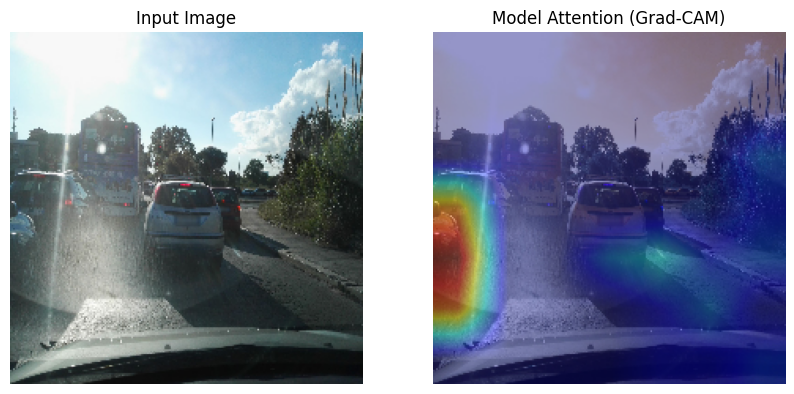

In [20]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 1. Instantiate missing variables by sampling the downloaded dataset
if 'df' not in locals() or df.empty:
    raise NameError("The dataframe 'df' is empty or not defined. Run the downloader script first.")

sample_row = df.iloc[0]
test_path = sample_row['path']

# 2. Preprocess the image into a 4D tensor for the model
# Ensure 'transform' and 'device' are defined from your previous setup
img = Image.open(test_path).convert('RGB')
tensor = transform(img).unsqueeze(0).to(device)
tensor.requires_grad = True  # Enable gradients for CAM extraction

# 3. Generate the prediction index required for visualize_cam
model.eval()
with torch.set_grad_enabled(True): # Must allow gradient flow for CAM
    output = model(tensor)
    pred_idx = torch.argmax(output, dim=1).item()

# 4. Generate the heatmap
heatmap = visualize_cam(model, tensor, pred_idx)

# 5. Render the overlay
img_bgr = cv2.imread(test_path)
img_bgr = cv2.resize(img_bgr, (224, 224))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
overlay = cv2.addWeighted(img_bgr, 0.6, heatmap_color, 0.4, 0)

# 6. Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title("Model Attention (Grad-CAM)")
plt.axis('off')

plt.show()